# Task 1: EDA for Translation Evaluation Dataset Preparation

This notebook explores `HuggingFaceTB/cosmopedia_stanford_openstax_wiki_1k` and turns the raw corpus into concrete design decisions for an English to Indonesian translation evaluation dataset. The emphasis is not just descriptive statistics, but identifying risks that could bias or weaken the final benchmark.

## Notebook Legend

<div style="background-color:#e3f2fd; color:#111827; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Blue: Method / Decision Context</strong><br>
Explains why a step is included, what assumption is being made, or how the analysis supports the dataset-preparation plan.
</div>

<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Green: Finding / Implication</strong><br>
Summarizes the main conclusion after an EDA output and states how it affects filtering, sampling, reference generation, QA, or interpretation.
</div>

<div style="background-color:#fff8e1; color:#111827; border-left:6px solid #f9a825; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Yellow: Caveat / Limitation</strong><br>
Flags limitations that should be remembered when interpreting the dataset or the downstream evaluation.
</div>

<div style="background-color:#f3e5f5; color:#111827; border-left:6px solid #6a1b9a; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Purple: Discussion Answer</strong><br>
Directly answers the assessment discussion questions.
</div>


<div style="background-color:#e3f2fd; color:#111827; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Method.</strong><br>
This notebook is intentionally EDA-only. It does not generate Indonesian references or run model inference; those steps belong in the dataset-preparation and evaluation scripts so they can be rerun reproducibly on Kaggle or through the SEA-LION API.
</div>


In [1]:
# Environment and imports
# Keep dependencies lightweight and notebook-friendly. WordCloud is optional; the notebook
# falls back to a deterministic bar chart if the package is unavailable.
from pathlib import Path
from collections import Counter, defaultdict
import os
import re
import tempfile
import textwrap
import warnings
import contextlib
import io

# Put runtime caches in a writable temporary directory to avoid noisy notebook warnings.
CACHE_DIR = Path(tempfile.gettempdir()) / "aisg_eval_notebook_cache"
(CACHE_DIR / "matplotlib").mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "xdg").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR / "matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR / "xdg"))
os.environ.setdefault("ARROW_USER_SIMD_LEVEL", "NONE")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
try:
    from huggingface_hub.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

try:
    from wordcloud import WordCloud, STOPWORDS as WORDCLOUD_STOPWORDS
    WORDCLOUD_AVAILABLE = True
except ModuleNotFoundError:
    WordCloud = None
    WORDCLOUD_STOPWORDS = set()
    WORDCLOUD_AVAILABLE = False

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

DATASET_NAME = "HuggingFaceTB/cosmopedia_stanford_openstax_wiki_1k"
LOCAL_PARQUET = Path("cosmopedia_stanford_openstax_wiki_1k/data/train-00000-of-00001.parquet")
RANDOM_SEED = 42

print(f"WordCloud available: {WORDCLOUD_AVAILABLE}")
print(f"Notebook cache directory: {CACHE_DIR}")


WordCloud available: True
Notebook cache directory: /var/folders/7w/s77vdsln3jg1nd2wfcgqjwqm0000gn/T/aisg_eval_notebook_cache


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Reproducibility Implication.</strong><br>
The EDA is designed to run without installing extra packages. That matters for Kaggle: optional visual polish such as a word cloud should never become a dependency bottleneck, so the notebook falls back to a deterministic term-frequency chart when `wordcloud` is unavailable.
</div>


## 1. Load Dataset


In [2]:
# Load from Hugging Face first, with a local parquet fallback for offline or restricted environments.
load_error = None
try:
    with contextlib.redirect_stderr(io.StringIO()):
        dataset = load_dataset(DATASET_NAME)
    df = dataset["train"].to_pandas()
    data_source = f"Hugging Face Hub: {DATASET_NAME}"
except Exception as exc:
    load_error = repr(exc)
    if not LOCAL_PARQUET.exists():
        raise FileNotFoundError(
            f"Could not load {DATASET_NAME} and local fallback does not exist: {LOCAL_PARQUET}"
        ) from exc
    df = pd.read_parquet(LOCAL_PARQUET)
    data_source = f"Local parquet fallback: {LOCAL_PARQUET}"

print(f"Data source: {data_source}")
if load_error:
    print(f"Hub load fallback reason: {load_error[:300]}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Column names: {list(df.columns)}")

display(df.head(3))

dtype_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(dtype) for dtype in df.dtypes],
    "non_null_count": [df[col].notna().sum() for col in df.columns],
    "unique_count": [df[col].nunique(dropna=False) for col in df.columns],
})
display(dtype_summary)


Data source: Hugging Face Hub: HuggingFaceTB/cosmopedia_stanford_openstax_wiki_1k
Rows: 3,000
Columns: 6
Column names: ['text_token_length', 'prompt', 'text', 'seed_data', 'format', 'audience']


,text_token_length,prompt,text,seed_data,format,audience
0,527,"Write a long and very detailed course unit for a textbook on ""10 French Women Who Changed History"" intended for professionals and researchers in the field.\...","1.1 Overview of the Course\n\nIn this comprehensive textbook, we delve into the lives and achievements of ten influential French women who left indelible m...",stanford,textbook_narrative,researchers
1,681,"Write a long and very detailed course unit for a textbook on ""Fourth-Year Japanese, Second Quarter"" intended for young children.\nWe have already covered ch...","Congratulations, fourth-grade friends! You've made it to the final chapter of our exciting journey through Fourth-Year Japanese. We've learned so much toge...",stanford,textbook_narrative,young_children
2,266,"Write a long and very detailed course unit for a textbook on ""The Chinese Empire from the Mongol Invasion to the Boxer Uprising "" intended for college stude...","9.3 Impact of Ethnic Conflict on Chinese Society\n\nIn this section, we will explore the various ways in which ethnic conflict has shaped Chinese society t...",stanford,textbook_narrative,college_students


,column,dtype,non_null_count,unique_count
0,text_token_length,int64,3000,1225
1,prompt,str,3000,3000
2,text,str,3000,3000
3,seed_data,str,3000,1
4,format,str,3000,1
5,audience,str,3000,4


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Benchmark Scope Implication.</strong><br>
This is a compact synthetic educational corpus: 3,000 generated textbook-style passages, all from the same seed family. That makes it well suited for evaluating long-form educational translation, but it should not be overclaimed as a benchmark for every genre such as dialogue, social media, legal text, or production customer content.
</div>


## 2. Dataset Health Checks


In [3]:
text_series = df["text"].astype(str)
empty_text_mask = text_series.str.strip().eq("")

dataset_health = pd.DataFrame([
    {"metric": "total_rows", "value": len(df)},
    {"metric": "total_columns", "value": len(df.columns)},
    {"metric": "missing_text_rows", "value": int(df["text"].isna().sum())},
    {"metric": "empty_or_whitespace_text_rows", "value": int(empty_text_mask.sum())},
    {"metric": "duplicate_text_rows", "value": int(text_series.duplicated().sum())},
    {"metric": "unique_text_rows", "value": int(text_series.nunique())},
])

display(dataset_health)

missing_by_column = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
)
display(missing_by_column)

metadata_uniques = []
for column in ["seed_data", "format", "audience"]:
    counts = df[column].value_counts(dropna=False).rename_axis(column).reset_index(name="count")
    counts["pct"] = (counts["count"] / len(df) * 100).round(2)
    counts.insert(0, "column", column)
    metadata_uniques.append(counts.rename(columns={column: "value"}))
metadata_uniques = pd.concat(metadata_uniques, ignore_index=True)
display(metadata_uniques)


,metric,value
0,total_rows,3000
1,total_columns,6
2,missing_text_rows,0
3,empty_or_whitespace_text_rows,0
4,duplicate_text_rows,0
5,unique_text_rows,3000


,missing_count,missing_pct
text_token_length,0,0.0
prompt,0,0.0
text,0,0.0
seed_data,0,0.0
format,0,0.0
audience,0,0.0


,column,value,count,pct
0,seed_data,stanford,3000,100.00
1,format,textbook_narrative,3000,100.00
2,audience,young_children,785,26.17
3,audience,college_students,745,24.83
4,audience,researchers,737,24.57
5,audience,high_school_studnets,733,24.43


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Data Reliability Implication.</strong><br>
The raw dataset is structurally clean: no missing values, no empty passages, and no duplicate passages. This removes the need for imputation or duplicate handling, so the main dataset-construction risk is not data cleanliness; it is representativeness, length balance, and avoiding incomplete-looking fragments.
</div>


## 3. Text-Derived Feature Engineering


In [4]:
# Build features only from the text column so the eventual sampling strategy is compatible
# with the instruction that the final evaluation dataset should use only text.
eda = df.copy()
eda["text_clean"] = text_series.str.replace(r"\s+", " ", regex=True).str.strip()
eda["char_count"] = text_series.str.len()
eda["word_count"] = text_series.str.split().str.len()
eda["line_count"] = text_series.str.count("\n") + 1
eda["paragraph_count"] = text_series.str.count(r"\n\s*\n") + 1
eda["sentence_count_approx"] = text_series.str.count(r"[.!?]+(?=\s|$)")
eda["newline_count"] = text_series.str.count("\n")
eda["newline_density_per_1k_chars"] = (eda["newline_count"] / eda["char_count"].clip(lower=1) * 1000).round(2)
eda["avg_words_per_sentence_approx"] = (
    eda["word_count"] / eda["sentence_count_approx"].replace(0, np.nan)
).round(2)
eda["contains_number"] = text_series.str.contains(r"\d", regex=True)
eda["contains_structured_marker"] = text_series.str.contains(r"(?:^|\n)\s*(?:[-*]|\d+[.)])\s+", regex=True)
eda["starts_with_heading_like_pattern"] = text_series.str.strip().str.contains(r"^(?:\*\*)?\d+(?:\.\d+)*\b", regex=True)

feature_cols = [
    "char_count", "word_count", "sentence_count_approx", "paragraph_count", "line_count",
    "newline_density_per_1k_chars", "avg_words_per_sentence_approx",
]
feature_summary = eda[feature_cols].describe(percentiles=[.01, .05, .10, .25, .50, .75, .90, .95, .99]).round(2)
display(feature_summary)

boolean_summary = pd.DataFrame({
    "feature": ["contains_number", "contains_structured_marker", "starts_with_heading_like_pattern"],
    "count": [int(eda[col].sum()) for col in ["contains_number", "contains_structured_marker", "starts_with_heading_like_pattern"]],
})
boolean_summary["pct"] = (boolean_summary["count"] / len(eda) * 100).round(2)
display(boolean_summary)

correlation_summary = eda[feature_cols].corr(numeric_only=True).round(3)
display(correlation_summary)


,char_count,word_count,sentence_count_approx,paragraph_count,line_count,newline_density_per_1k_chars,avg_words_per_sentence_approx
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,2992.00
mean,4891.39,690.29,35.76,15.27,34.19,6.87,20.09
std,1704.72,217.39,12.77,6.60,17.11,2.88,4.68
min,18.00,3.00,0.00,1.00,1.00,0.00,6.01
1%,836.63,119.99,4.99,4.00,7.00,2.82,11.40
5%,2472.70,386.00,18.00,7.00,13.00,3.58,13.53
10%,2940.00,451.90,23.00,8.00,16.00,4.10,14.79
25%,3730.00,557.00,28.00,10.00,22.00,5.06,16.87
50%,4792.50,669.00,34.00,15.00,32.00,6.30,19.61
75%,5853.25,809.00,42.00,19.00,43.00,8.02,22.82


,feature,count,pct
0,contains_number,2988,99.60
1,contains_structured_marker,1333,44.43
2,starts_with_heading_like_pattern,2467,82.23


,char_count,word_count,sentence_count_approx,paragraph_count,line_count,newline_density_per_1k_chars,avg_words_per_sentence_approx
char_count,1.000,0.970,0.695,0.676,0.620,-0.084,0.183
word_count,0.970,1.000,0.738,0.674,0.625,-0.061,0.147
sentence_count_approx,0.695,0.738,1.000,0.591,0.604,0.112,-0.476
paragraph_count,0.676,0.674,0.591,1.000,0.913,0.508,-0.000
line_count,0.620,0.625,0.604,0.913,1.000,0.643,-0.027
newline_density_per_1k_chars,-0.084,-0.061,0.112,0.508,0.643,1.000,-0.152
avg_words_per_sentence_approx,0.183,0.147,-0.476,-0.000,-0.027,-0.152,1.000


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Inference Design Implication.</strong><br>
The corpus is document-like, not sentence-pair-like. The median passage is about 669 words, 15 paragraphs, and 34 approximate sentences, with many numbered or structured sections. A translation pipeline that sends entire rows through a short-context MT model would likely truncate or flatten structure, so reference generation should be chunked by paragraph or sentence and should track formatting preservation.
</div>


## 4. Length Distributions and Outliers


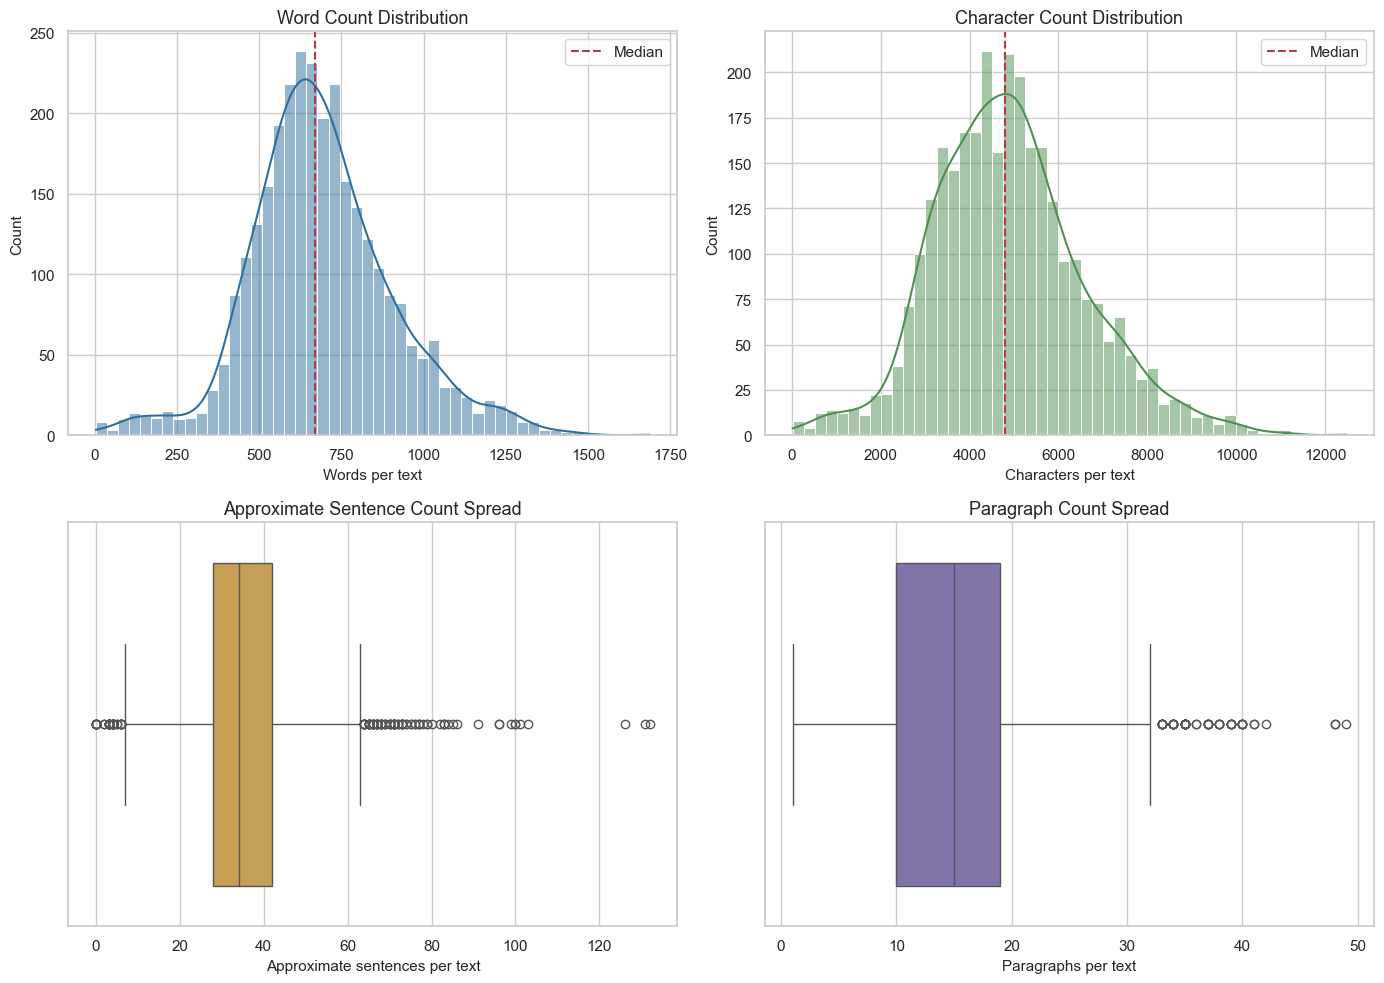

,threshold,row_count,pct
0,< 10 words,7,0.23
1,< 25 words,7,0.23
2,< 50 words,8,0.27
3,< 100 words,18,0.60
4,< 200 words,56,1.87
5,< 300 words,91,3.03


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(eda["word_count"], bins=50, kde=True, ax=axes[0, 0], color="#2f6f9f")
axes[0, 0].set_title("Word Count Distribution")
axes[0, 0].set_xlabel("Words per text")
axes[0, 0].axvline(eda["word_count"].median(), color="#b23a48", linestyle="--", label="Median")
axes[0, 0].legend()

sns.histplot(eda["char_count"], bins=50, kde=True, ax=axes[0, 1], color="#4f8f52")
axes[0, 1].set_title("Character Count Distribution")
axes[0, 1].set_xlabel("Characters per text")
axes[0, 1].axvline(eda["char_count"].median(), color="#b23a48", linestyle="--", label="Median")
axes[0, 1].legend()

sns.boxplot(x=eda["sentence_count_approx"], ax=axes[1, 0], color="#d9a441")
axes[1, 0].set_title("Approximate Sentence Count Spread")
axes[1, 0].set_xlabel("Approximate sentences per text")

sns.boxplot(x=eda["paragraph_count"], ax=axes[1, 1], color="#7d6bb3")
axes[1, 1].set_title("Paragraph Count Spread")
axes[1, 1].set_xlabel("Paragraphs per text")

plt.tight_layout()
plt.show()

threshold_summary = pd.DataFrame({
    "threshold": ["< 10 words", "< 25 words", "< 50 words", "< 100 words", "< 200 words", "< 300 words"],
    "row_count": [
        int((eda["word_count"] < 10).sum()),
        int((eda["word_count"] < 25).sum()),
        int((eda["word_count"] < 50).sum()),
        int((eda["word_count"] < 100).sum()),
        int((eda["word_count"] < 200).sum()),
        int((eda["word_count"] < 300).sum()),
    ],
})
threshold_summary["pct"] = (threshold_summary["row_count"] / len(eda) * 100).round(2)
display(threshold_summary)


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Filtering Implication.</strong><br>
The length distribution has a healthy middle mass plus a small but important low-length tail. The 100-word cutoff is not arbitrary: it removes only 18 rows, preserves 99.4% of the corpus, and targets the examples most likely to be partial headings or failed generations rather than complete educational material.
</div>


In [6]:
def make_snippet(text, width=260):
    compact = re.sub(r"\s+", " ", str(text)).strip()
    return textwrap.shorten(compact, width=width, placeholder=" ...")

short_examples = (
    eda.nsmallest(10, "word_count")
    .assign(snippet=lambda x: x["text"].map(make_snippet))
    [["word_count", "char_count", "sentence_count_approx", "paragraph_count", "audience", "snippet"]]
)
long_examples = (
    eda.nlargest(10, "word_count")
    .assign(snippet=lambda x: x["text"].map(make_snippet))
    [["word_count", "char_count", "sentence_count_approx", "paragraph_count", "audience", "snippet"]]
)

print("Shortest examples by word count")
display(short_examples)
print("Longest examples by word count")
display(long_examples)


Shortest examples by word count


,word_count,char_count,sentence_count_approx,paragraph_count,audience,snippet
2177,3,18,0,1,high_school_studnets,4.4 Monthly Liver
1336,4,18,0,1,college_students,4.1 Review of CS1
2804,4,18,0,1,high_school_studnets,3.2 Tehran in 197
2034,5,39,0,2,college_students,4.2 Privatization and Market Reforms
345,8,54,0,1,young_children,**1.2 The Importance of Studying African American and
1329,8,64,0,2,college_students,4.2 International Criminal Tribunal for the former Yugoslavia
2893,8,49,0,1,researchers,5.3 Guest Speaker: Digital Strategist from a 202
2352,28,193,0,2,college_students,**7.1 Grounding Historical Reading in Attention to Current Events** The world has been grappling with an unprecedented global financial crisis triggered by ...
1291,58,333,2,3,high_school_studnets,"8.2 The Future of German Space Exploration As we come to the end of our journey through the history of German space exploration, you may be wondering what l..."
1498,61,355,2,2,high_school_studnets,"1.2 Review of Concepts Covered in Financial Markets I (F620) Welcome back to our journey through the world of finance! In this section, we will briefly revi..."


Longest examples by word count


,word_count,char_count,sentence_count_approx,paragraph_count,audience,snippet
1069,1688,12477,49,22,college_students,"2.1 Historical Perspectives on the Doctor/Patient Relationship The relationship between doctors and patients has evolved significantly over time, reflecting..."
1281,1506,10952,65,31,researchers,"1.2 The Importance of Studying Medieval Rus' and Early Modern Russian Literature As scholars and researchers in the field of Slavic studies, we are well awa..."
1167,1460,10149,68,18,college_students,"4.1 Career Opportunities in Genetic Counseling As you progress through your education and training as a genetic counselor, it's natural to start thinking ab..."
574,1455,11189,56,18,researchers,"4.2 Data Protection Regulations in Latin America Introduction Data has become one of the most valuable assets in today's digital age, driving innovation, ec..."
1161,1440,9443,64,41,college_students,"3.2 Intuitionistic Operators In our study of intuitionistic logic, we now turn our attention to the intuitionistic operators, which allow us to build comple..."
1578,1430,11068,57,34,high_school_studnets,5.6 Leveragable Assets / Inherited Liabilities As we continue our exploration of the similarities and differences between the sports industry and other indu...
1991,1411,9880,62,37,researchers,"10.2 Properties of Markov Chain Monte Carlo Methods In this section, we will delve deeper into the properties of MCMC methods, focusing on their convergence..."
912,1406,8885,73,39,high_school_studnets,"5.1 Introduction to Programming for Laptop Orchestras Welcome to the exciting world of programming for laptop orchestras! You might be thinking, “Programmin..."
1948,1405,9946,65,25,researchers,"5.1 Anatomic Terminology: The Rosetta Stone of Human Anatomy As we delve into the intricate world of the genitourinary system, it is crucial to establish a ..."
667,1378,8920,54,28,high_school_studnets,3.1 Aristotle's Theory of Perception: Seeing the World Through Ancient Eyes Introduction Have you ever wondered how we perceive the world around us? How do ...


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Stress-Test Implication.</strong><br>
The extremes reveal two different actions. Very short fragments should be filtered because they would make the evaluation artificially easy and noisy. Very long passages should be kept because they test a realistic weakness of LLM translation systems: maintaining adequacy, terminology, and structure over multi-paragraph content.
</div>


## 5. Audience, Format, and Source Metadata


Audience distribution


,audience,count,pct
0,young_children,785,26.17
1,college_students,745,24.83
2,researchers,737,24.57
3,high_school_studnets,733,24.43


Format distribution


,format,count,pct
0,textbook_narrative,3000,100.0


Seed-data distribution


,seed_data,count,pct
0,stanford,3000,100.0


,rows,mean_words,median_words,min_words,max_words,mean_paragraphs,mean_sentences
audience,,,,,,,
researchers,737,764.45,751.0,8,1506,16.45,35.75
college_students,745,749.18,722.0,4,1688,16.64,37.23
high_school_studnets,733,697.13,680.0,3,1430,16.21,37.08
young_children,785,558.41,547.0,8,1146,11.97,33.15


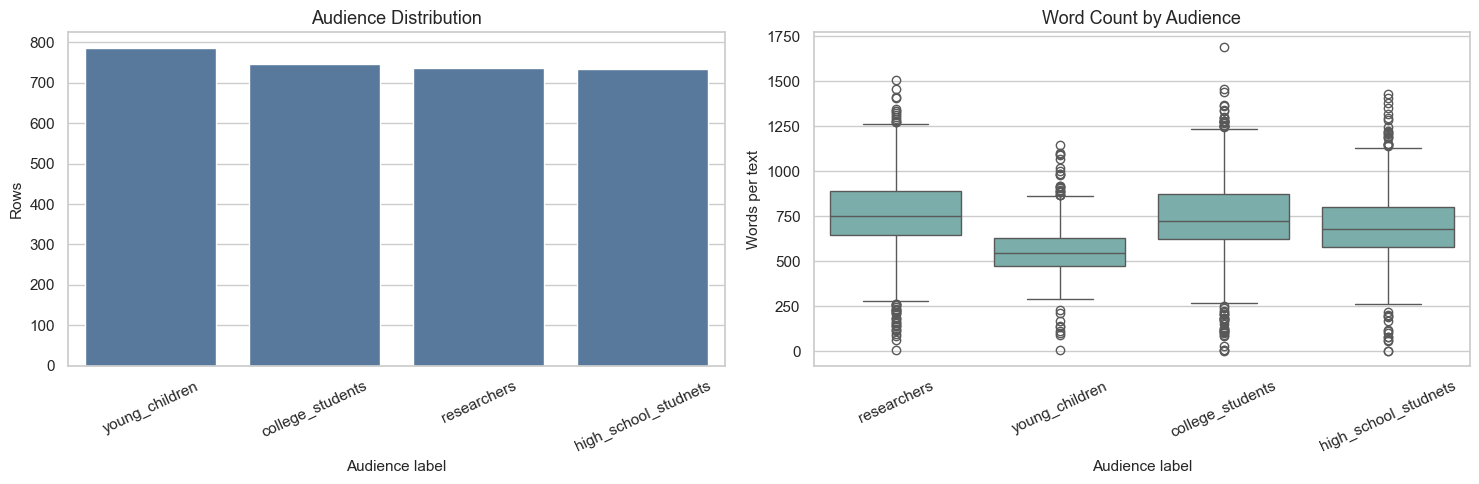

In [7]:
audience_counts = df["audience"].value_counts().rename_axis("audience").reset_index(name="count")
audience_counts["pct"] = (audience_counts["count"] / len(df) * 100).round(2)
format_counts = df["format"].value_counts().rename_axis("format").reset_index(name="count")
format_counts["pct"] = (format_counts["count"] / len(df) * 100).round(2)
seed_counts = df["seed_data"].value_counts().rename_axis("seed_data").reset_index(name="count")
seed_counts["pct"] = (seed_counts["count"] / len(df) * 100).round(2)

print("Audience distribution")
display(audience_counts)
print("Format distribution")
display(format_counts)
print("Seed-data distribution")
display(seed_counts)

audience_length_summary = (
    eda.groupby("audience")
    .agg(
        rows=("text", "size"),
        mean_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        min_words=("word_count", "min"),
        max_words=("word_count", "max"),
        mean_paragraphs=("paragraph_count", "mean"),
        mean_sentences=("sentence_count_approx", "mean"),
    )
    .round(2)
    .sort_values("median_words", ascending=False)
)
display(audience_length_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=audience_counts, x="audience", y="count", ax=axes[0], color="#4c78a8")
axes[0].set_title("Audience Distribution")
axes[0].set_xlabel("Audience label")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(data=eda, x="audience", y="word_count", ax=axes[1], color="#72b7b2")
axes[1].set_title("Word Count by Audience")
axes[1].set_xlabel("Audience label")
axes[1].set_ylabel("Words per text")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Sampling Implication.</strong><br>
The metadata is useful diagnostically but weak as a primary sampling axis. `format` and `seed_data` are constant, while `audience` is balanced but noisy, including the typo `high_school_studnets`. This points toward text-derived stratification, especially length and structure, instead of relying on metadata labels that add little diversity or may encode annotation noise.
</div>


## 6. Content and Topic Signals


In [8]:
# Lightweight stopword list tailored for English educational text.
BASE_STOPWORDS = set("a an and are as at be been being by can could did do does doing for from had has have having he her here him his how i if in into is it its itself just may more most must no not of on or our ours out over own same she should so some such than that the their theirs them then there these they this those through to too under until up very was we were what when where which while who whom why will with you your yours".split())
DOMAIN_STOPWORDS = set("chapter course section unit students student learning learn learners textbook example examples use using used also one two first second new key important different provide include includes including focus understanding knowledge concepts concept topic topics discuss discussion explore exploring study studies".split())
STOPWORDS = BASE_STOPWORDS | DOMAIN_STOPWORDS | set(WORDCLOUD_STOPWORDS)

TOKEN_RE = re.compile(r"[a-z][a-z']+")

def extract_tokens(text):
    tokens = TOKEN_RE.findall(str(text).lower())
    return [token.strip("'") for token in tokens if len(token.strip("'")) >= 3 and token not in STOPWORDS]

unigram_counter = Counter()
bigram_counter = Counter()
audience_token_counters = defaultdict(Counter)

for _, row in eda.iterrows():
    tokens = extract_tokens(row["text"])
    unigram_counter.update(tokens)
    bigram_counter.update(" ".join(pair) for pair in zip(tokens, tokens[1:]))
    audience_token_counters[row["audience"]].update(tokens)

top_unigrams = pd.DataFrame(unigram_counter.most_common(25), columns=["term", "count"])
top_bigrams = pd.DataFrame(bigram_counter.most_common(25), columns=["bigram", "count"])

audience_top_terms = []
for audience, counter in sorted(audience_token_counters.items()):
    for rank, (term, count) in enumerate(counter.most_common(10), start=1):
        audience_top_terms.append({"audience": audience, "rank": rank, "term": term, "count": count})
audience_top_terms = pd.DataFrame(audience_top_terms)

print("Top unigrams")
display(top_unigrams)
print("Top bigrams")
display(top_bigrams)
print("Top terms by audience")
display(audience_top_terms.pivot(index="rank", columns="audience", values="term"))


Top unigrams


,term,count
0,time,3756
1,world,3617
2,within,3432
3,research,3345
4,data,2740
5,various,2710
6,social,2502
7,challenges,2322
8,many,2224
9,might,2183


Top bigrams


,bigram,count
0,real world,985
1,quad quad,731
2,decision making,605
3,valuable insights,549
4,delve deeper,438
5,climate change,437
6,welcome back,356
7,research findings,351
8,critical thinking,335
9,crucial role,331


Top terms by audience


audience,college_students,high_school_studnets,researchers,young_children
rank,,,,
1,within,world,research,time
2,research,time,within,world
3,data,within,data,make
4,world,various,various,might
5,social,research,challenges,people
6,time,social,social,now
7,various,might,complex,imagine
8,complex,complex,quad,together
9,challenges,consider,time,help


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Coverage Implication.</strong><br>
The top terms and bigrams show broad educational coverage rather than one dominant subject: language learning, history, research methods, science, writing, and social topics all appear. This is useful for model comparison because translation quality will depend on terminology handling, not just generic fluency.
</div>


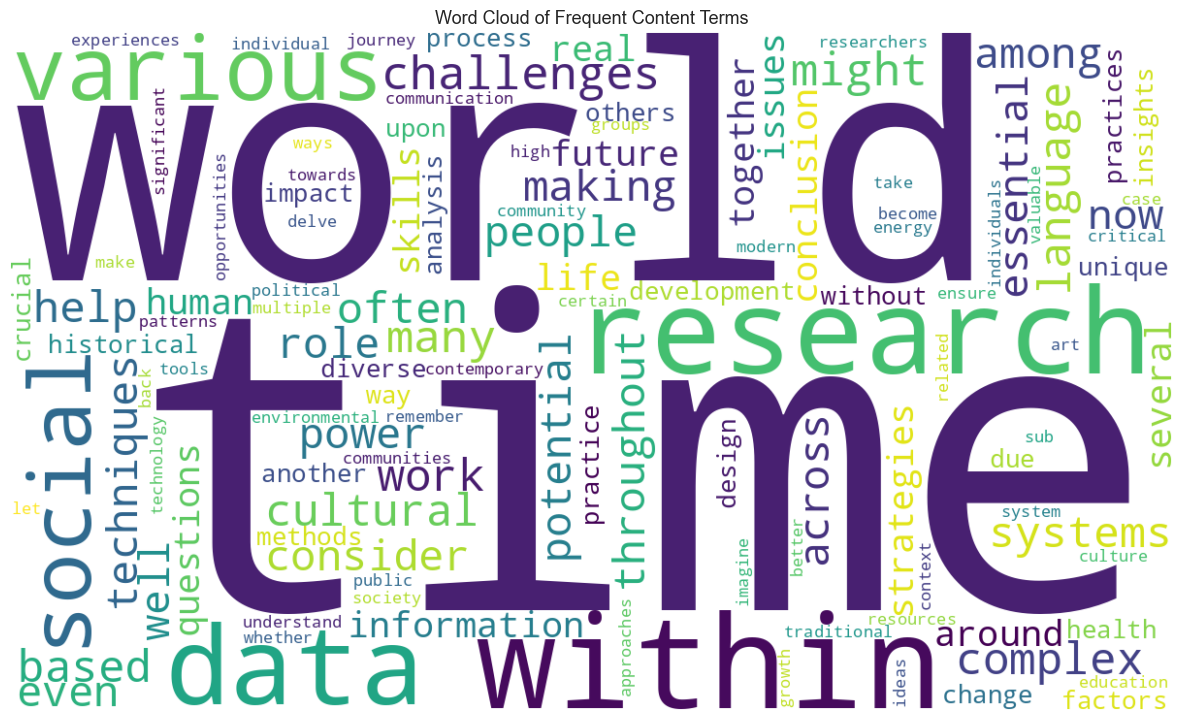

In [9]:
fig, ax = plt.subplots(figsize=(12, 8))

if WORDCLOUD_AVAILABLE:
    cloud = WordCloud(
        width=1200,
        height=700,
        background_color="white",
        colormap="viridis",
        stopwords=STOPWORDS,
        random_state=RANDOM_SEED,
        max_words=120,
    ).generate_from_frequencies(unigram_counter)
    ax.imshow(cloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Word Cloud of Frequent Content Terms")
else:
    plot_terms = top_unigrams.sort_values("count", ascending=True).tail(25)
    sns.barplot(data=plot_terms, x="count", y="term", ax=ax, color="#4c78a8")
    ax.set_title("Top Content Terms (WordCloud Package Not Installed)")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Term")

plt.tight_layout()
plt.show()


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Content-Diversity Implication.</strong><br>
The keyword visualization is not just decorative: it checks whether the corpus is dominated by boilerplate. The observed term spread suggests the evaluation set should preserve topic variety during automated QA, because a length-balanced sample can still accidentally overrepresent a few educational themes.
</div>


## 7. Objective Topic Modeling for Coverage


<div style="background-color:#e3f2fd; color:#111827; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Method / Topic Modeling Decision.</strong><br>
Objective topic modeling is included as a coverage diagnostic, not as the primary sampling strategy. BERTopic would be a reasonable option in a richer environment, but it adds substantial embedding and clustering dependencies. For this assessment notebook, a lightweight TF-IDF + Latent Semantic Analysis (SVD) approach is enough to identify broad latent content clusters and check whether the eventual sample accidentally drops a major topic.
</div>

,topic,assigned_rows,assigned_pct,mean_words,median_words,explained_share,top_terms
0,topic_01,2795,93.17,696.6,674.0,0.0965,"research, data, language, social, cultural, work, challenges, people, systems, might, skills, techniques"
1,topic_02,37,1.23,554.4,572.0,0.0193,"cultural, political, social, american, historical, identity, contemporary, gender, culture, rights, literature, history"
2,topic_03,45,1.50,545.8,547.0,0.0188,"data, research, systems, health, energy, methods, models, applications, researchers, design, management, environmental"
3,topic_04,9,0.30,434.9,477.0,0.0132,"language, research, data, linguistic, vocabulary, writing, skills, languages, cultural, reading, listening, speakers"
4,topic_05,11,0.37,665.6,658.0,0.0125,"research, health, education, community, skills, project, policy, goals, communication, organizations, everyone, social"
5,topic_06,30,1.00,662.3,679.0,0.0092,"language, energy, linguistic, vocabulary, languages, water, speakers, native, health, english, listening, cells"
6,topic_07,15,0.50,732.7,730.0,0.0085,"data, language, languages, linguistic, probability, law, rights, legal, model, variables, gender, analysis"
7,topic_08,58,1.93,632.6,664.0,0.0083,"health, healthcare, care, patients, medical, medicine, cells, mental, patient, treatment, genetic, clinical"


length_tercile,short,medium,long
lsa_topic,,,
topic_01,0.327,0.334,0.339
topic_02,0.541,0.351,0.108
topic_03,0.644,0.244,0.111
topic_04,0.778,0.111,0.111
topic_05,0.364,0.273,0.364
topic_06,0.133,0.600,0.267
topic_07,0.333,0.333,0.333
topic_08,0.345,0.293,0.362


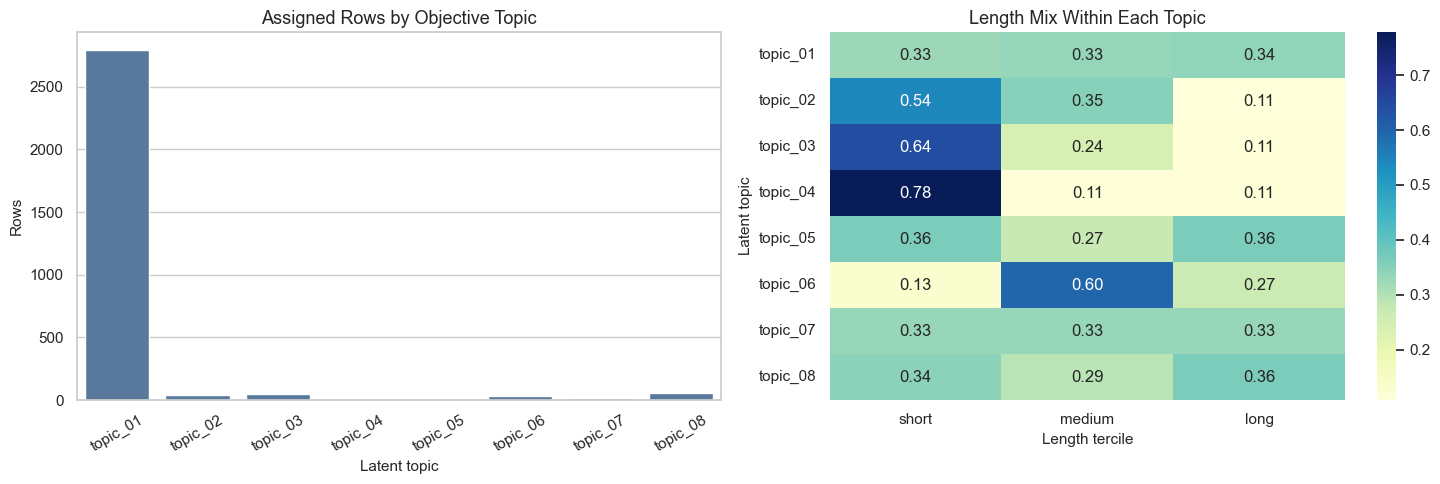

In [10]:
# Objective topic modeling using TF-IDF + truncated SVD/LSA implemented with NumPy.
# This is fitted on the corpus before sampling, then used after an initial
# length-stratified sample as a coverage audit rather than a hard sampling label.
MAX_VOCAB = 1200
MIN_DOC_FREQ = 5
MAX_DOC_FREQ_RATIO = 0.60
N_TOPICS = 8
TOP_TERMS_PER_TOPIC = 12

# Reuse the tokenization and stopword logic from the content analysis section.
doc_tokens = [extract_tokens(text) for text in eda["text"]]
n_docs = len(doc_tokens)

term_frequency = Counter()
document_frequency = Counter()
for tokens in doc_tokens:
    term_frequency.update(tokens)
    document_frequency.update(set(tokens))

candidate_terms = [
    term for term, _ in term_frequency.most_common()
    if document_frequency[term] >= MIN_DOC_FREQ
    and document_frequency[term] <= n_docs * MAX_DOC_FREQ_RATIO
]
vocab = candidate_terms[:MAX_VOCAB]
term_to_idx = {term: idx for idx, term in enumerate(vocab)}

X = np.zeros((n_docs, len(vocab)), dtype=np.float32)
for row_idx, tokens in enumerate(doc_tokens):
    counts = Counter(token for token in tokens if token in term_to_idx)
    total = sum(counts.values())
    if total == 0:
        continue
    for token, count in counts.items():
        X[row_idx, term_to_idx[token]] = count / total

df_vector = np.array([document_frequency[term] for term in vocab], dtype=np.float32)
idf = np.log((1 + n_docs) / (1 + df_vector)) + 1
X *= idf

# Normalize rows so topics are not simply length clusters.
row_norms = np.linalg.norm(X, axis=1, keepdims=True)
X_norm = X / np.where(row_norms == 0, 1, row_norms)

# Eigen-decomposition of the feature Gram matrix is efficient here because the vocabulary
# is capped. This gives the right singular vectors/components for LSA.
gram = X_norm.T @ X_norm
eigenvalues, eigenvectors = np.linalg.eigh(gram)
order = np.argsort(eigenvalues)[::-1][:N_TOPICS]
components = eigenvectors[:, order].T
topic_strength = eigenvalues[order]
explained_share = topic_strength / eigenvalues.sum()

doc_scores = X_norm @ components.T
topic_assignments = np.argmax(np.abs(doc_scores), axis=1)
eda["lsa_topic"] = [f"topic_{idx + 1:02d}" for idx in topic_assignments]

topic_rows = []
for topic_idx, component in enumerate(components):
    # SVD signs are arbitrary. Flip each component so its strongest loading is positive.
    strongest_idx = int(np.argmax(np.abs(component)))
    sign = 1 if component[strongest_idx] >= 0 else -1
    oriented = component * sign
    top_indices = np.argsort(oriented)[::-1][:TOP_TERMS_PER_TOPIC]
    top_terms = [vocab[idx] for idx in top_indices]
    topic_label = f"topic_{topic_idx + 1:02d}"
    topic_mask = eda["lsa_topic"].eq(topic_label)
    topic_rows.append({
        "topic": topic_label,
        "assigned_rows": int(topic_mask.sum()),
        "assigned_pct": round(topic_mask.mean() * 100, 2),
        "mean_words": round(eda.loc[topic_mask, "word_count"].mean(), 1),
        "median_words": round(eda.loc[topic_mask, "word_count"].median(), 1),
        "explained_share": round(float(explained_share[topic_idx]), 4),
        "top_terms": ", ".join(top_terms),
    })

topic_summary = pd.DataFrame(topic_rows)
display(topic_summary)

# Check whether latent topics are entangled with document length. If a topic is present only
# in long or short passages, the final sample should account for that during QA.
topic_length_view = eda.copy()
topic_length_view["length_tercile"] = pd.qcut(
    topic_length_view["word_count"],
    q=3,
    labels=["short", "medium", "long"],
    duplicates="drop",
)
topic_length_crosstab = pd.crosstab(
    topic_length_view["lsa_topic"],
    topic_length_view["length_tercile"],
    normalize="index",
).round(3)
display(topic_length_crosstab)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=topic_summary, x="topic", y="assigned_rows", ax=axes[0], color="#4c78a8")
axes[0].set_title("Assigned Rows by Objective Topic")
axes[0].set_xlabel("Latent topic")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=30)

sns.heatmap(topic_length_crosstab, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Length Mix Within Each Topic")
axes[1].set_xlabel("Length tercile")
axes[1].set_ylabel("Latent topic")
plt.tight_layout()
plt.show()


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Topic-Coverage Implication.</strong><br>
The LSA topics are useful, but only as a secondary audit. Length is directly measurable and therefore a better primary stratification variable; unsupervised topic assignments are approximate and should not be forced into equal quotas. The practical use is post-sampling: after drawing a length-balanced sample, compare its latent-topic distribution against the eligible pool and replace within the same length bucket only if a major topic disappears or is severely underrepresented.
</div>

## 8. Sampling Design for the Final Evaluation Dataset


,metric,value
0,original_rows,3000
1,rows_after_filter_word_count_ge_100,2982
2,removed_rows,18
3,target_eval_rows,300
4,target_rows_per_length_bucket,100


,available_rows,min_words,median_words,max_words,mean_words,planned_sample_rows,planned_sample_pct_of_bucket
length_bucket,,,,,,,
short,1001,102,511.0,599,482.98,100,9.99
medium,994,600,672.0,753,674.73,100,10.06
long,987,754,889.0,1688,927.94,100,10.13


,sampled_rows,min_words,median_words,max_words
length_bucket,,,,
short,100,114,529.5,595
medium,100,602,675.5,753
long,100,762,890.5,1430


,eligible_pool_share,candidate_sample_share,absolute_share_gap
lsa_topic,,,
topic_01,0.933,0.913,0.020
topic_02,0.012,0.023,0.011
topic_03,0.015,0.013,0.001
topic_04,0.003,0.000,0.003
topic_05,0.004,0.003,0.000
topic_06,0.010,0.020,0.010
topic_07,0.005,0.010,0.005
topic_08,0.018,0.017,0.002


Major topics missing from candidate sample: 0


,n,worst_case_95pct_moe_on_0_1_metric,worst_case_95pct_moe_on_0_100_metric,paired_mde_as_fraction_of_sd_80pct_power
0,100,0.098,9.8,0.280
1,200,0.069,6.9,0.198
2,300,0.057,5.7,0.162
3,500,0.044,4.4,0.125
4,1000,0.031,3.1,0.089


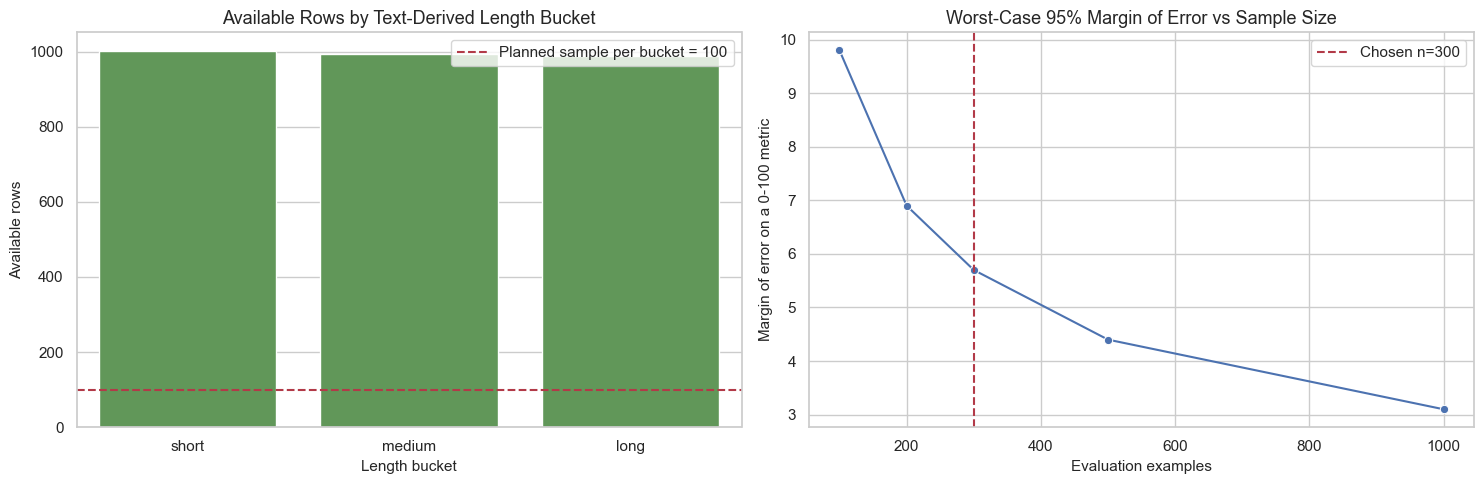

In [11]:

MIN_WORDS = 100
TARGET_EVAL_SIZE = 300
TARGET_PER_BUCKET = TARGET_EVAL_SIZE // 3

valid_pool = eda.loc[eda["word_count"] >= MIN_WORDS].copy()
valid_pool["length_bucket"] = pd.qcut(
    valid_pool["word_count"],
    q=3,
    labels=["short", "medium", "long"],
    duplicates="drop",
)
if "lsa_topic" in eda.columns:
    valid_pool["lsa_topic"] = eda.loc[valid_pool.index, "lsa_topic"]

bucket_summary = (
    valid_pool.groupby("length_bucket", observed=True)
    .agg(
        available_rows=("text", "size"),
        min_words=("word_count", "min"),
        median_words=("word_count", "median"),
        max_words=("word_count", "max"),
        mean_words=("word_count", "mean"),
    )
    .round(2)
)
bucket_summary["planned_sample_rows"] = TARGET_PER_BUCKET
bucket_summary["planned_sample_pct_of_bucket"] = (
    bucket_summary["planned_sample_rows"] / bucket_summary["available_rows"] * 100
).round(2)

display(pd.DataFrame([
    {"metric": "original_rows", "value": len(eda)},
    {"metric": f"rows_after_filter_word_count_ge_{MIN_WORDS}", "value": len(valid_pool)},
    {"metric": "removed_rows", "value": len(eda) - len(valid_pool)},
    {"metric": "target_eval_rows", "value": TARGET_EVAL_SIZE},
    {"metric": "target_rows_per_length_bucket", "value": TARGET_PER_BUCKET},
]))
display(bucket_summary)

# Deterministic candidate sample used only for EDA validation of the proposed sampling rule.
candidate_sample = (
    valid_pool
    .groupby("length_bucket", observed=True, group_keys=False)
    .sample(n=TARGET_PER_BUCKET, random_state=RANDOM_SEED)
    .sort_index()
)

sample_length_summary = (
    candidate_sample.groupby("length_bucket", observed=True)
    .agg(
        sampled_rows=("text", "size"),
        min_words=("word_count", "min"),
        median_words=("word_count", "median"),
        max_words=("word_count", "max"),
    )
    .round(2)
)
display(sample_length_summary)

if "lsa_topic" in valid_pool.columns:
    eligible_topic_share = valid_pool["lsa_topic"].value_counts(normalize=True).sort_index()
    sample_topic_share = candidate_sample["lsa_topic"].value_counts(normalize=True).reindex(eligible_topic_share.index, fill_value=0)
    topic_audit = pd.DataFrame({
        "eligible_pool_share": eligible_topic_share,
        "candidate_sample_share": sample_topic_share,
    })
    topic_audit["absolute_share_gap"] = (topic_audit["candidate_sample_share"] - topic_audit["eligible_pool_share"]).abs()
    topic_audit = topic_audit.round(3)
    display(topic_audit)

    major_topic_threshold = 0.05
    undercovered_topics = topic_audit.loc[
        (topic_audit["eligible_pool_share"] >= major_topic_threshold)
        & (topic_audit["candidate_sample_share"] == 0)
    ]
    print(f"Major topics missing from candidate sample: {len(undercovered_topics)}")
    if len(undercovered_topics):
        display(undercovered_topics)

# Statistical precision and paired-comparison backing for n=300.
# For bounded per-example quantities on a 0-1 scale, the worst-case 95% margin of error
# for a mean/proportion is 1.96 * sqrt(0.25 / n). For paired model differences, the
# approximate minimum detectable effect is (z_0.975 + z_0.80) * sigma_d / sqrt(n).
z_975 = 1.96
z_power_80 = 0.84
precision_rows = []
for n in [100, 200, 300, 500, 1000]:
    worst_case_moe = z_975 * np.sqrt(0.25 / n)
    paired_mde_sigma_units = (z_975 + z_power_80) / np.sqrt(n)
    precision_rows.append({
        "n": n,
        "worst_case_95pct_moe_on_0_1_metric": round(worst_case_moe, 3),
        "worst_case_95pct_moe_on_0_100_metric": round(worst_case_moe * 100, 1),
        "paired_mde_as_fraction_of_sd_80pct_power": round(paired_mde_sigma_units, 3),
    })
precision_table = pd.DataFrame(precision_rows)
display(precision_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=bucket_summary.reset_index(),
    x="length_bucket",
    y="available_rows",
    ax=axes[0],
    color="#59a14f",
)
axes[0].axhline(TARGET_PER_BUCKET, color="#b23a48", linestyle="--", label=f"Planned sample per bucket = {TARGET_PER_BUCKET}")
axes[0].set_title("Available Rows by Text-Derived Length Bucket")
axes[0].set_xlabel("Length bucket")
axes[0].set_ylabel("Available rows")
axes[0].legend()

sns.lineplot(data=precision_table, x="n", y="worst_case_95pct_moe_on_0_100_metric", marker="o", ax=axes[1])
axes[1].axvline(TARGET_EVAL_SIZE, color="#b23a48", linestyle="--", label="Chosen n=300")
axes[1].set_title("Worst-Case 95% Margin of Error vs Sample Size")
axes[1].set_xlabel("Evaluation examples")
axes[1].set_ylabel("Margin of error on a 0-100 metric")
axes[1].legend()
plt.tight_layout()
plt.show()


### Statistical Rationale for 300 Examples

The final sample size is not statistically "proven" in a universal sense; no fixed sample size guarantees stable rankings for every possible metric and model pair. The justification is a transparent precision/power tradeoff.

For an aggregate metric computed as a mean over examples,

$$
\hat{\mu}=\frac{1}{n}\sum_{i=1}^{n}m_i, \qquad SE(\hat{\mu})=\frac{s_m}{\sqrt{n}}.
$$

For a bounded pass/fail-style quantity, the worst-case 95% margin of error is

$$
MOE_{95}\leq 1.96\sqrt{\frac{0.25}{n}}.
$$

For paired model comparison, using per-example score differences $d_i$, an approximate 80%-power detectable paired effect is

$$
\Delta_{min}\approx \frac{(z_{0.975}+z_{0.80})\sigma_d}{\sqrt{n}}
\approx \frac{2.80\sigma_d}{\sqrt{n}}.
$$

At $n=300$, the worst-case 95% margin of error is about 5.7 points on a 0-100 scale, and the paired detectable effect is about $0.16\sigma_d$. Within each length bucket, $n=100$ gives a coarser but still interpretable subgroup view: about 9.8 points worst-case margin of error and about $0.28\sigma_d$ paired detectable effect.


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Sample-Size Implication.</strong><br>
After filtering short fragments, 2,982 rows remain. A 300-row design gives 100 examples per length bucket, making every bucket large enough for interpretable subgroup metrics while keeping the overall evaluation feasible. Statistically, n=300 gives a worst-case 95% margin of error of about 5.7 points on a 0-100 bounded metric and can detect paired model differences of roughly 0.16 standard deviations under standard normal approximations. Topic modeling is used only to audit the candidate sample after length stratification, not to define hard quotas.
</div>

## 9. Evaluation Dataset Design Implications


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Synthesis / Design Implications.</strong><br>
<table style="border-collapse:collapse; width:100%; margin-top:8px;">
<thead><tr>
<th style="border:1px solid #a7c8a9; padding:6px; text-align:left;">EDA signal</th>
<th style="border:1px solid #a7c8a9; padding:6px; text-align:left;">Risk if ignored</th>
<th style="border:1px solid #a7c8a9; padding:6px; text-align:left;">Dataset response</th>
</tr></thead>
<tbody>
<tr><td style="border:1px solid #a7c8a9; padding:6px;">Incomplete short tail</td><td style="border:1px solid #a7c8a9; padding:6px;">Inflated scores from trivial fragments</td><td style="border:1px solid #a7c8a9; padding:6px;">Filter rows under 100 words</td></tr>
<tr><td style="border:1px solid #a7c8a9; padding:6px;">Long structured documents</td><td style="border:1px solid #a7c8a9; padding:6px;">Truncated or structure-losing references</td><td style="border:1px solid #a7c8a9; padding:6px;">Use chunked generation and formatting checks</td></tr>
<tr><td style="border:1px solid #a7c8a9; padding:6px;">One format and one seed family</td><td style="border:1px solid #a7c8a9; padding:6px;">Overgeneralizing beyond educational prose</td><td style="border:1px solid #a7c8a9; padding:6px;">State benchmark scope clearly</td></tr>
<tr><td style="border:1px solid #a7c8a9; padding:6px;">Broad length distribution</td><td style="border:1px solid #a7c8a9; padding:6px;">Metrics dominated by common mid-length rows</td><td style="border:1px solid #a7c8a9; padding:6px;">Sample evenly across length terciles</td></tr>
<tr><td style="border:1px solid #a7c8a9; padding:6px;">Objective latent topics</td><td style="border:1px solid #a7c8a9; padding:6px;">Length-balanced sample still misses major content clusters</td><td style="border:1px solid #a7c8a9; padding:6px;">Fit topics on eligible pool; audit candidate sample and replace within length buckets only if a major topic is absent</td></tr>
<tr><td style="border:1px solid #a7c8a9; padding:6px;">No human Indonesian references</td><td style="border:1px solid #a7c8a9; padding:6px;">Pseudo-reference errors become evaluation noise</td><td style="border:1px solid #a7c8a9; padding:6px;">Use automated quality gates, regeneration, and replacement</td></tr>
</tbody></table>
</div>


## 10. Indonesian and SEA-HELM Rationale


<div style="background-color:#e3f2fd; color:#111827; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Decision Context.</strong><br>
Indonesian is selected because it is directly covered by SEA-HELM and has Indonesian-specific model rankings for translation-oriented evaluation. That gives both the target language and reference-generation model choice an external benchmark basis. SEA-HELM documentation: <a href="https://docs.sea-lion.ai/benchmarks/sea-helm">https://docs.sea-lion.ai/benchmarks/sea-helm</a>. Indonesian leaderboard: <a href="https://leaderboard.sea-lion.ai/detailed/ID">https://leaderboard.sea-lion.ai/detailed/ID</a>.
</div>


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Finding / Model-Selection Implication.</strong><br>
SEA-HELM makes Indonesian a stronger choice than a language selected only by personal comfort. The later generation step should choose models from the Indonesian SEA-HELM translation results, then document the selected model, prompt, generation settings, and reference-quality feedback loop so the pseudo-reference process is auditable.
</div>


## 11. Automated Reference Generation and QA Plan


<div style="background-color:#e3f2fd; color:#111827; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Generation Model Decision.</strong><br>
Use a SEA-HELM-guided SEA-LION generator for Indonesian pseudo-references. The recommended default is <code>aisingapore/Gemma-SEA-LION-v4-27B-IT</code> / SEA-LION v4 27B, because the Indonesian SEA-HELM translation task ranks SEA-LION v4 27B very near the top among open instruct models (Translations: 93.51±0.03), close to Gemma 3 27B (93.59±0.02), while also being SEA-specialized and available through the SEA-LION ecosystem. SEA-LION documentation also lists Indonesian among the supported languages and a 128K context length, which is useful for long educational passages. The generation script should still chunk by paragraph/sentence for controllability and retry handling.
</div>

<div style="background-color:#e3f2fd; color:#111827; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Automated QA and Feedback Loop.</strong><br>
Use both reference-free COMETKiwi and a judge LLM, but for different purposes. Deterministic gates run first: non-empty output, Indonesian language identification, source/reference length ratio, chunk-count consistency, heading/numbering preservation, copy-rate checks, and repeated-text detection. Then score every generated pseudo-reference with a reference-free QE model such as <code>Unbabel/wmt22-cometkiwi-da</code> when feasible; use distribution-based thresholds such as bottom-decile or IQR outlier flags because there is no human gold score to calibrate an absolute cutoff. Finally, use the judge LLM on rows flagged by deterministic gates or COMETKiwi, plus a small random audit slice if API budget allows. Rows that fail any hard gate, fall into the COMETKiwi risk band, or receive low judge adequacy/format scores should be regenerated with smaller chunks or stricter prompts; persistent failures should be replaced by another source row from the same length bucket and, where possible, a similar latent topic.
</div>

<div style="background-color:#e3f2fd; color:#111827; border-left:6px solid #1565c0; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Judge Model Decision.</strong><br>
Do not use the same model as both generator and judge unless no alternative is available. If <code>Gemma-SEA-LION-v4-27B-IT</code> is the generator, the preferred SEA-LION judge is SEA-LION v3 (Llama) 70B / <code>aisingapore/llama3.1-70b-cpt-sea-lionv3-instruct</code> when available. It is a different architecture and remains strong on Indonesian SEA-HELM, including Translations: 92.90±0.05. This reduces self-preference compared with asking the generator to grade its own outputs. If SEA-LION v3 70B is unavailable through the served API, use the strongest available non-generator model from the SEA-HELM Indonesian leaderboard; otherwise keep LLM judging disabled and rely on deterministic QA plus reference-free QE.
</div>


<div style="background-color:#fff8e1; color:#111827; border-left:6px solid #f9a825; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>COMETKiwi and Judge Limitations.</strong><br>
COMETKiwi is useful because it estimates translation quality from source and translation without a reference, but it is still a learned metric and may be imperfect for long educational passages. The judge LLM can inspect adequacy, terminology, and structure more explicitly, but it can also be biased or inconsistent. Treat both as complementary QA signals for triage and regeneration, not as proof that the pseudo-reference is human-gold quality. Final Task 2 model comparison should still report automatic metrics against the pseudo-reference set and clearly state that the references are machine-generated.
</div>

<div style="background-color:#fff8e1; color:#111827; border-left:6px solid #f9a825; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Limitation / No Human Ground Truth.</strong><br>
This process produces audited pseudo-references, not human gold references. The final writeup should be explicit about that distinction. The value of the feedback loop is to reduce obvious reference noise before Task 2, but model scores should still be interpreted as performance against high-quality machine-generated references rather than against professional human translations.
</div>


## 12. Task 1 Discussion Questions


<div style="background-color:#f3e5f5; color:#111827; border-left:6px solid #6a1b9a; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Discussion Question 1: Were there any notable findings from the EDA?</strong><br>
Yes. The notable findings are the ones that affect benchmark design: the corpus is clean enough to use without imputation; it is homogeneous in format and seed source, so scope should be described as educational long-form translation; it has a small incomplete-looking short tail that should be filtered; it has broad length variation that requires length-stratified sampling; it contains structured, multi-paragraph content, so reference generation must avoid truncation; and objective latent topic modeling is useful as a sample-coverage audit, not as a primary source of labels.
</div>

<div style="background-color:#f3e5f5; color:#111827; border-left:6px solid #6a1b9a; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Discussion Question 2: How did you choose the samples to create the final dataset?</strong><br>
I would remove incomplete-looking rows under 100 words, then stratify the remaining pool by word-count terciles. The goal is to make the final set challenging across short, medium, and long educational passages rather than letting random sampling concentrate around the median. After drawing the length-balanced candidate sample, I would audit its latent-topic distribution against the eligible pool and replace within the same length bucket only if a major topic cluster is absent or severely underrepresented.
</div>

<div style="background-color:#f3e5f5; color:#111827; border-left:6px solid #6a1b9a; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Discussion Question 3: How did you decide on the final size of the evaluation dataset?</strong><br>
I would use 300 examples: 100 per length band. This is a statistically backed precision/power tradeoff: for bounded aggregate metrics it gives a worst-case 95% margin of error of about 5.7 points on a 0-100 scale, and for paired model comparisons it can detect differences of about 0.16 standard deviations under standard normal approximations. It is also operationally feasible under Kaggle runtime and SEA-LION API rate limits, leaving room for automated pseudo-reference regeneration and replacement.
</div>

<div style="background-color:#fff8e1; color:#111827; border-left:6px solid #f9a825; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Limitation / Quality-Control Requirement.</strong><br>
No human Indonesian ground-truth references are provided, and no subject-matter experts are assumed to be available. The generated Indonesian references must therefore be treated as audited pseudo-references. The dataset-preparation pipeline should rely on automated checks, reference-free quality estimation when available, regeneration for weak rows, and replacement of examples that remain weak after retries. This limitation should be reported in the final writeup and considered when interpreting Task 2 metrics.
</div>

## 13. EDA Conclusions


<div style="background-color:#e8f5e9; color:#111827; border-left:6px solid #2e7d32; padding:12px 14px; border-radius:4px; margin:10px 0;">
<strong>Final EDA Conclusion.</strong><br>
The EDA changes the dataset design in seven concrete ways: filter under-100-word fragments, preserve long passages as stress tests, stratify by word-count tercile, justify n=300 with explicit precision/power calculations, use objective topic modeling only as a post-sampling coverage audit, choose Indonesian/generation candidates using SEA-HELM, and require an automated pseudo-reference QA loop combining deterministic checks, reference-free COMETKiwi, and a separate judge model when available. The resulting evaluation set will be strongest as a focused benchmark for long-form educational translation, not as a universal translation benchmark across all genres.
</div>

## References

- SEA-HELM Indonesian leaderboard: <https://leaderboard.sea-lion.ai/detailed/ID>
- Gemma-SEA-LION-v4-27B documentation: <https://docs.sea-lion.ai/models/sea-lion-v4/gemma-sea-lion-v4-27b>
- SEA-LION v3 Llama 70B model card: <https://huggingface.co/aisingapore/Llama-SEA-LION-v3-70B>
- COMET documentation: <https://unbabel.github.io/COMET/html/index.html>
- COMET metrics and reference-free QE models: <https://unbabel.github.io/COMET/html/models.html>
- Unbabel COMET GitHub usage notes, including reference-free COMETKiwi scoring: <https://github.com/Unbabel/COMET>
- Unbabel quality-estimation model collection: <https://huggingface.co/collections/Unbabel/quality-estimation>
